# Estimación del valor de mercado de futbolistas profesionales

## Notebook 3 — Interpretabilidad y aplicación de negocio

**Trabajo Fin de Máster** · Máster en Big Data, Data Science e Inteligencia Artificial · Universidad Complutense de Madrid

---

### Qué hace este notebook

| | |
|---|---|
| **Consume** | `models/modelo_final.joblib`, `data/processed/predicciones_test.parquet` |
| **Produce** | Ranking de jugadores infravalorados y función de inferencia |
| **Alimenta** | Capítulos 6 (Interpretabilidad), 7 (Aplicación de negocio) y 8 (Empaquetado) |

### Estructura

1. **Interpretabilidad global** — qué determina el valor de un futbolista
2. **Efectos no lineales** — cómo influye cada factor a lo largo de su rango
3. **Interpretabilidad local** — tres jugadores explicados en detalle
4. **Identificación de infravalorados** — añadido como análisis de resultados
5. **Empaquetado** — función de inferencia sobre nuevos datos

---
## 0. Configuración y carga de artefactos

In [2]:
from pathlib import Path
import warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

PROJ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INTERIM   = PROJ / "data" / "interim"
PROCESSED = PROJ / "data" / "processed"
MODELS    = PROJ / "models"
FIGURES   = PROJ / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# --- Artefactos del notebook 2 ----------------------------------------------
art    = joblib.load(MODELS / "modelo_final.joblib")
modelo = art["modelo"]
COLS   = art["columnas"]
CATS   = art["cat_nombres"]
IDXCAT = art["cat_features"]
DUAN   = art["factor_duan"]
CUANT  = art["cuantiles"]
INDICE = art["indice_mercado"]

te = pd.read_parquet(PROCESSED / "predicciones_test.parquet")
a  = pd.read_parquet(PROCESSED / "dataset_analitico.parquet")

# Nombres de jugador y club, solo para legibilidad de los ejemplos
players = pd.read_parquet(INTERIM / "players.parquet")[["player_id", "name"]]
clubs   = pd.read_parquet(INTERIM / "clubs.parquet")[["club_id", "name"]] \
            .rename(columns={"name": "club"})
te = te.merge(players, on="player_id", how="left").merge(clubs, on="club_id", how="left")

print(f"Conjunto de prueba: {len(te):,} filas | {te['player_id'].nunique():,} jugadores")
print(f"Variables del modelo: {len(COLS)} ({len(CATS)} categóricas)")
print(f"Factor de Duan: {DUAN:.4f}")

Conjunto de prueba: 1,844 filas | 1,844 jugadores
Variables del modelo: 28 (4 categóricas)
Factor de Duan: 1.0487


In [3]:
%load_ext watermark
%watermark -v -p pandas,numpy,catboost,shap

Python implementation: CPython
Python version       : 3.11.15
IPython version      : 9.16.1

pandas  : 3.0.5
numpy   : 2.4.6
catboost: 1.2.10
shap    : 0.51.0



---
# 1. Interpretabilidad global

Los valores SHAP reparten la predicción de cada observación entre las variables que
intervienen, de forma que la suma de contribuciones más el valor esperado reproduce
exactamente la predicción. En modelos de árboles el cálculo es **exacto**, no aproximado.

Se emplea la implementación nativa de CatBoost, que respeta el tratamiento interno de las
variables categóricas.

In [4]:
from catboost import Pool

pool_te = Pool(te[COLS], te["y_log_defl"], cat_features=IDXCAT)

# ShapValues devuelve n_variables + 1 columnas; la última es el valor esperado
sv = modelo.get_feature_importance(pool_te, type="ShapValues")
shap_val  = sv[:, :-1]
valor_esp = sv[0, -1]

expl = shap.Explanation(values=shap_val,
                        base_values=np.repeat(valor_esp, len(te)),
                        data=te[COLS].values,
                        feature_names=COLS)

print(f"Matriz SHAP: {shap_val.shape}")
print(f"Valor esperado (log): {valor_esp:.4f}  ->  "
      f"{np.expm1(valor_esp):.2f} veces la mediana de mercado")

# Comprobacion: SHAP debe reconstruir la prediccion
recon = shap_val.sum(axis=1) + valor_esp
print(f"Error máximo de reconstrucción: {np.abs(recon - te['pred_log']).max():.2e}")

Matriz SHAP: (1844, 28)
Valor esperado (log): 2.0145  ->  6.50 veces la mediana de mercado
Error máximo de reconstrucción: 8.88e-15


## 1.1. Importancia global de las variables

=== IMPORTANCIA GLOBAL (media del valor absoluto SHAP) ===
        variable  shap_medio_abs  %_del_total
            edad           0.398       20.100
club_valor_medio           0.371       18.700
   ratio_titular           0.224       11.300
            liga           0.116        5.900
           goles           0.073        3.700
      club_dif_g           0.068        3.400
        club_ppp           0.059        3.000
         minutos           0.058        2.900
        goles_90           0.055        2.800
   partidos_liga           0.054        2.700
       club_rank           0.051        2.600
        partidos           0.048        2.400
 min_por_partido           0.045        2.200
           ga_90           0.042        2.100
     jugo_europa           0.039        1.900
        position           0.037        1.900
    sub_position           0.037        1.900
      club_aforo           0.034        1.700
 n_competiciones           0.031        1.500
  asistencias_90     

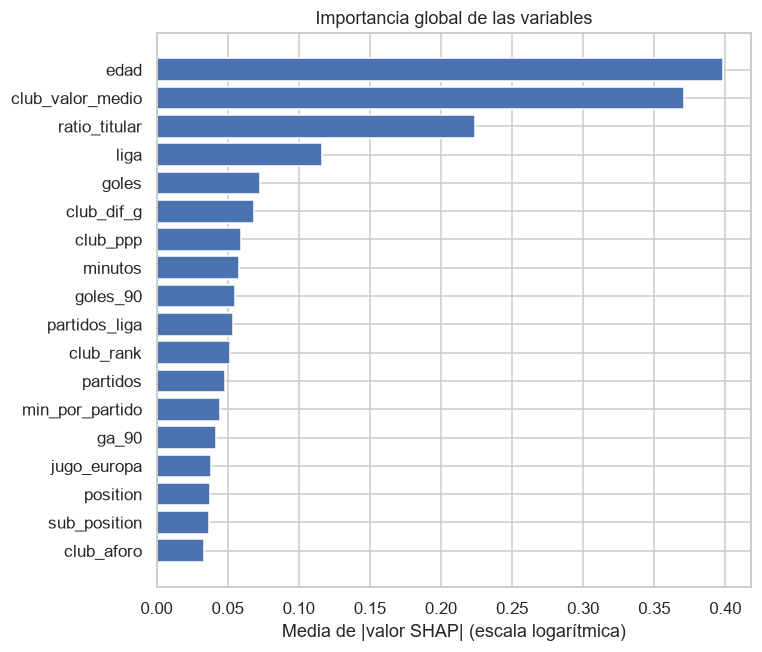

In [5]:
imp = (pd.DataFrame({"variable": COLS,
                     "shap_medio_abs": np.abs(shap_val).mean(axis=0)})
       .sort_values("shap_medio_abs", ascending=False, ignore_index=True))
imp["%_del_total"] = (100 * imp["shap_medio_abs"] / imp["shap_medio_abs"].sum()).round(1)

print("=== IMPORTANCIA GLOBAL (media del valor absoluto SHAP) ===")
print(imp.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 6))
top = imp.head(18).iloc[::-1]
ax.barh(top["variable"], top["shap_medio_abs"], color="#4C72B0")
ax.set_xlabel("Media de |valor SHAP| (escala logarítmica)")
ax.set_title("Importancia global de las variables")
fig.tight_layout(); fig.savefig(FIGURES / "fig9_shap_importancia.png", bbox_inches="tight")
plt.show()

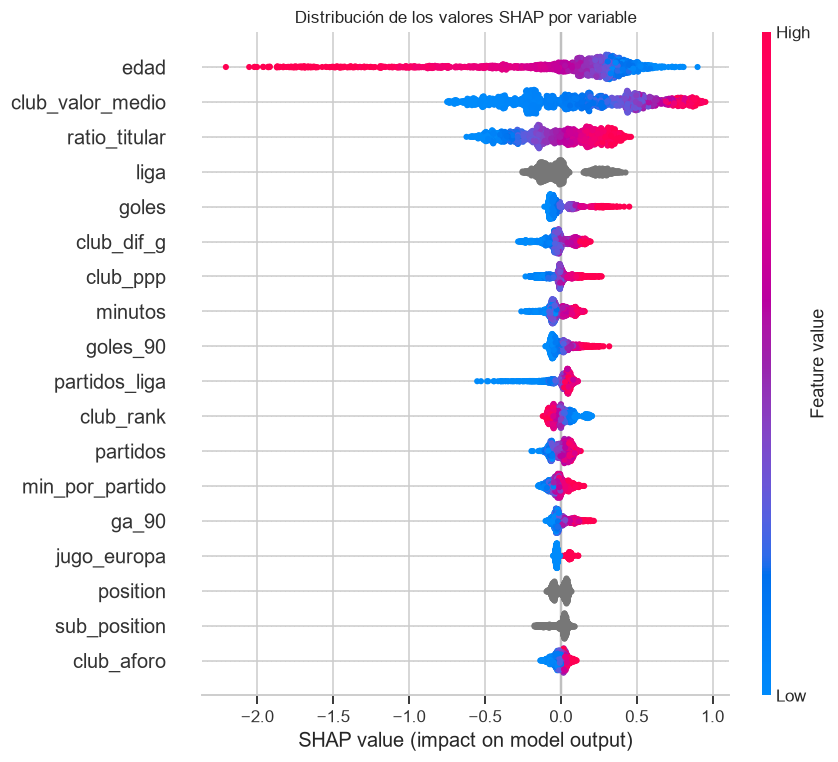

In [6]:
# Diagrama de dispersión SHAP: dirección y magnitud del efecto
fig = plt.figure(figsize=(8, 7))
shap.summary_plot(shap_val, te[COLS], feature_names=COLS,
                  max_display=18, show=False, plot_size=None)
plt.title("Distribución de los valores SHAP por variable", fontsize=11)
plt.tight_layout(); plt.savefig(FIGURES / "fig10_shap_beeswarm.png", bbox_inches="tight")
plt.show()

## 1.2. Importancia agrupada por bloques

Varias variables miden aspectos próximos y SHAP reparte el crédito entre ellas, de modo que
ninguna aparece como dominante por sí sola. Agrupar por bloques temáticos ofrece una lectura
más fiel de qué **tipo** de información sostiene la predicción.

=== IMPORTANCIA POR BLOQUE ===
          bloque  n_vars  shap_medio_abs  %_del_total
Contexto de club       6           0.700       35.200
          Perfil       5           0.500       25.200
   Rol y minutos       6           0.447       22.500
      Producción       5           0.225       11.400
     Competición       3           0.090        4.600
      Disciplina       3           0.023        1.100


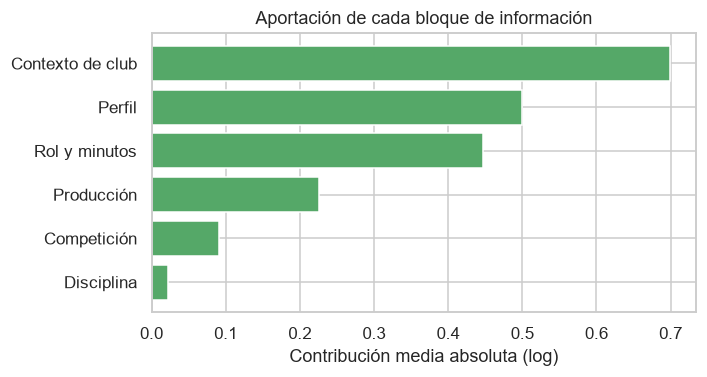


Variables no asignadas a ningún bloque: ninguna


In [7]:
BLOQUES = {
    "Contexto de club": ["club_ppp","club_dif_g","club_rank","club_valor_medio","club_aforo","liga"],
    "Rol y minutos":    ["minutos","partidos","min_por_partido","ratio_titular","capitanias",
                         "partidos_liga","convocatorias"],
    "Producción":       ["goles","asistencias","goles_90","asistencias_90","ga_90"],
    "Perfil":           ["edad","height_in_cm","position","sub_position","foot"],
    "Competición":      ["partidos_euro","n_competiciones","jugo_europa"],
    "Disciplina":       ["amarillas","rojas","amarillas_90"],
}

filas = []
for bloque, vs in BLOQUES.items():
    idx = [COLS.index(v) for v in vs if v in COLS]
    if idx:
        filas.append({"bloque": bloque, "n_vars": len(idx),
                      "shap_medio_abs": np.abs(shap_val[:, idx]).sum(axis=1).mean()})

bl = pd.DataFrame(filas).sort_values("shap_medio_abs", ascending=False, ignore_index=True)
bl["%_del_total"] = (100 * bl["shap_medio_abs"] / bl["shap_medio_abs"].sum()).round(1)
print("=== IMPORTANCIA POR BLOQUE ===")
print(bl.to_string(index=False))

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.barh(bl["bloque"].iloc[::-1], bl["shap_medio_abs"].iloc[::-1], color="#55A868")
ax.set_xlabel("Contribución media absoluta (log)")
ax.set_title("Aportación de cada bloque de información")
fig.tight_layout(); fig.savefig(FIGURES / "fig11_shap_bloques.png", bbox_inches="tight")
plt.show()

no_cubiertas = [c for c in COLS if not any(c in v for v in BLOQUES.values())]
print("\nVariables no asignadas a ningún bloque:", no_cubiertas if no_cubiertas else "ninguna")

---
# 2. Efectos no lineales

Los gráficos de dependencia muestran cómo varía la contribución de una variable a lo largo de
su rango. El eje vertical está en escala logarítmica, de modo que el efecto se lee de forma
multiplicativa sobre el valor.

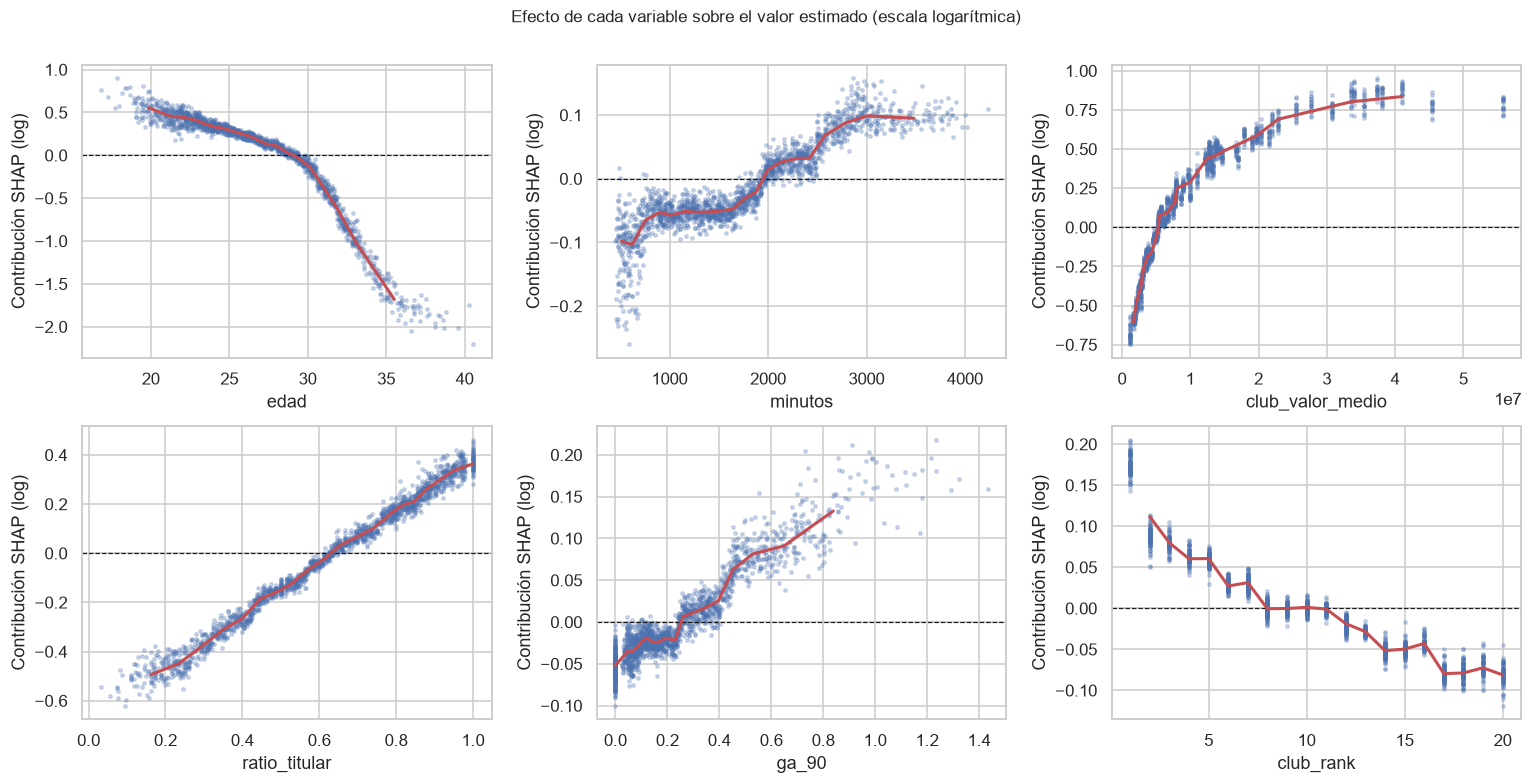

In [8]:
def dependencia(var, ax, color="#4C72B0"):
    i = COLS.index(var)
    x, y = te[var].values, shap_val[:, i]
    ax.scatter(x, y, s=5, alpha=.25, color=color)
    ax.axhline(0, c="k", lw=.8, ls="--")
    # Tendencia suavizada por percentiles
    if np.issubdtype(te[var].dtype, np.number):
        q = pd.qcut(te[var], min(20, te[var].nunique()), duplicates="drop")
        t = pd.DataFrame({"x": x, "y": y, "q": q}).groupby("q", observed=True).median()
        ax.plot(t["x"], t["y"], color="#C44E52", lw=2)
    ax.set_xlabel(var); ax.set_ylabel("Contribución SHAP (log)")

VARS = [v for v in ["edad","minutos","club_valor_medio","ratio_titular",
                    "ga_90","club_rank"] if v in COLS]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, v in zip(axes.ravel(), VARS):
    dependencia(v, ax)
fig.suptitle("Efecto de cada variable sobre el valor estimado (escala logarítmica)", y=1.01)
fig.tight_layout(); fig.savefig(FIGURES / "fig12_dependencia.png", bbox_inches="tight")
plt.show()

In [9]:
# Lectura del efecto de la edad en términos multiplicativos
i = COLS.index("edad")
tabla = (pd.DataFrame({"edad": te["edad"].round(), "shap": shap_val[:, i]})
         .groupby("edad").agg(n=("shap","size"), shap_medio=("shap","mean")))
tabla = tabla[tabla["n"] >= 20]
tabla["factor_multiplicativo"] = np.exp(tabla["shap_medio"]).round(3)

print("=== EFECTO DE LA EDAD ===")
print(tabla.round(3).to_string())
print("\nLectura: 'factor_multiplicativo' indica por cuánto multiplica la edad el valor")
print("estimado respecto a la media. Un 1,00 equivale a un efecto neutro.")

=== EFECTO DE LA EDAD ===
          n  shap_medio  factor_multiplicativo
edad                                          
19.000   23       0.573                  1.773
20.000   50       0.529                  1.696
21.000   81       0.462                  1.588
22.000  122       0.436                  1.547
23.000  148       0.395                  1.485
24.000  158       0.332                  1.394
25.000  158       0.294                  1.342
26.000  174       0.231                  1.260
27.000  169       0.162                  1.176
28.000  139       0.104                  1.109
29.000  130       0.005                  1.005
30.000  119      -0.124                  0.883
31.000   97      -0.379                  0.684
32.000   85      -0.664                  0.515
33.000   64      -0.950                  0.387
34.000   38      -1.287                  0.276
35.000   34      -1.542                  0.214

Lectura: 'factor_multiplicativo' indica por cuánto multiplica la edad el valor
e

---
# 3. Interpretabilidad local y análisis de jugadores infravalorados

In [10]:
# Los modelos cuantílicos guardados esperan sus propias columnas.
COLS_Q = list(CUANT[0.5].feature_names_)
print("Columnas del modelo principal :", len(COLS))
print("Columnas del modelo cuantílico:", len(COLS_Q))
print("Diferencia:", set(COLS_Q) ^ set(COLS))

IDXCAT_Q = [COLS_Q.index(c) for c in CATS if c in COLS_Q]
pool_q = Pool(te[COLS_Q], cat_features=IDXCAT_Q)

Columnas del modelo principal : 28
Columnas del modelo cuantílico: 28
Diferencia: set()


In [11]:
# Intervalo de estimación para todo el conjunto de prueba
q_lo = np.asarray(CUANT[0.1].predict(pool_q))
q_md = np.asarray(CUANT[0.5].predict(pool_q))
q_hi = np.asarray(CUANT[0.9].predict(pool_q))
q_lo, q_md, q_hi = np.sort(np.vstack([q_lo, q_md, q_hi]), axis=0)

ind = te["indice_mercado"].values
te["est_inf"] = np.exp(q_lo) * DUAN * ind
te["est_sup"] = np.exp(q_hi) * DUAN * ind
te["ratio_est_real"] = te["pred_eur"] / te["target_valor"]

te["señal"] = np.log(te["ratio_est_real"])
te["infravalorado"] = (te["target_valor"] < te["est_inf"]) & (te["minutos"] >= 900)

COLS_RK = ["name","club","liga","position","edad","partidos","minutos",
           "goles","asistencias","target_valor","pred_eur","est_inf","est_sup",
           "ratio_est_real","señal"]

def formatea(d):
    x = d[COLS_RK].copy()
    for c in ["target_valor","pred_eur","est_inf","est_sup"]:
        x[c] = (x[c]/1e6).round(2)
    return x.rename(columns={"target_valor":"real_M€","pred_eur":"est_M€",
                             "est_inf":"inf_M€","est_sup":"sup_M€",
                             "ratio_est_real":"ratio"}).round(2)

print("=== TOP 20 INFRAVALORADOS (temporada 2023/24) ===")
print(formatea(te[te["infravalorado"]].nlargest(20, "señal")).to_string(index=False))

print("\n\n=== TOP 15 SOBREVALORADOS ===")
sobre = (te["target_valor"] > te["est_sup"]) & (te["minutos"] >= 900)
print(formatea(te[sobre].nsmallest(15, "señal")).to_string(index=False))

=== TOP 20 INFRAVALORADOS (temporada 2023/24) ===
                   name                       club liga position   edad  partidos  minutos  goles  asistencias  real_M€  est_M€  inf_M€  sup_M€  ratio  señal
          Matteo Gabbia                   AC Milan  IT1 Defender 24.530        35     2591      2            1    8.000  26.880  16.360  38.940  3.360  1.210
           Ashley Young                 Everton FC  GB1 Defender 38.810        28     2043      0            0    0.500   1.680   0.770   3.670  3.360  1.210
          Jack Robinson           Sheffield United  GB1 Defender 30.660        32     2706      1            1    1.000   3.290   2.170   6.980  3.290  1.190
             Adam Smith            AFC Bournemouth  GB1 Defender 33.010        27     2107      0            2    1.000   3.240   1.720   5.230  3.240  1.170
             Ben Osborn           Sheffield United  GB1 Midfield 29.740        24     1336      0            2    1.000   2.950   1.950   7.140  2.950  1.080
  

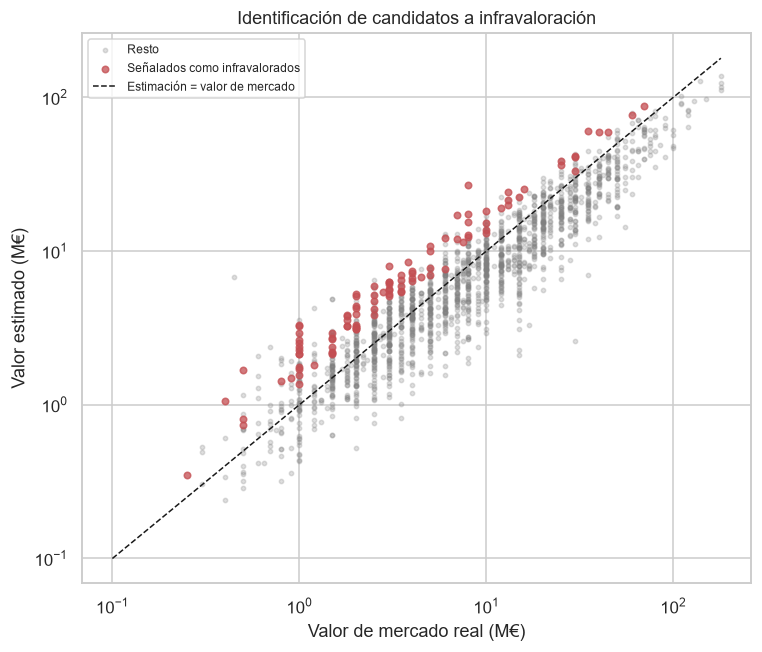

In [12]:
# Visualización: estimado frente a real, con los señalados destacados
fig, ax = plt.subplots(figsize=(7, 6))

resto = te[~te["infravalorado"]]
ax.scatter(resto["target_valor"]/1e6, resto["pred_eur"]/1e6,
           s=8, alpha=.25, color="grey", label="Resto")
sel = te[te["infravalorado"]]
ax.scatter(sel["target_valor"]/1e6, sel["pred_eur"]/1e6,
           s=18, alpha=.75, color="#C44E52", label="Señalados como infravalorados")

lim = [0.1, te["target_valor"].max()/1e6]
ax.plot(lim, lim, "k--", lw=1, label="Estimación = valor de mercado")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Valor de mercado real (M€)"); ax.set_ylabel("Valor estimado (M€)")
ax.set_title("Identificación de candidatos a infravaloración")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIGURES / "fig15_ranking.png", bbox_inches="tight")
plt.show()

=== CANDIDATOS CON TEMPORADA COMPLETA ===
            name             club liga position   edad  partidos  minutos  goles  asistencias  target_valor       pred_eur        est_inf
   Matteo Gabbia         AC Milan  IT1 Defender 24.528        35     2591      2            1 8,000,000.000 26,883,261.533 16,364,613.260
    Ashley Young       Everton FC  GB1 Defender 38.812        28     2043      0            0   500,000.000  1,679,585.369    770,286.740
   Jack Robinson Sheffield United  GB1 Defender 30.664        32     2706      1            1 1,000,000.000  3,294,483.781  2,168,265.510
      Adam Smith  AFC Bournemouth  GB1 Defender 33.008        27     2107      0            2 1,000,000.000  3,236,775.488  1,718,288.802
Luca de la Torre    Celta de Vigo  ES1 Midfield 25.941        32     2087      3            6 3,000,000.000  8,042,014.823  4,228,694.876

CASO DE INFRAVALORACIÓN — Matteo Gabbia
  AC Milan (IT1) | Defender | 24.53 años
  35 partidos, 2591 min, 2 goles, 1 asistencias


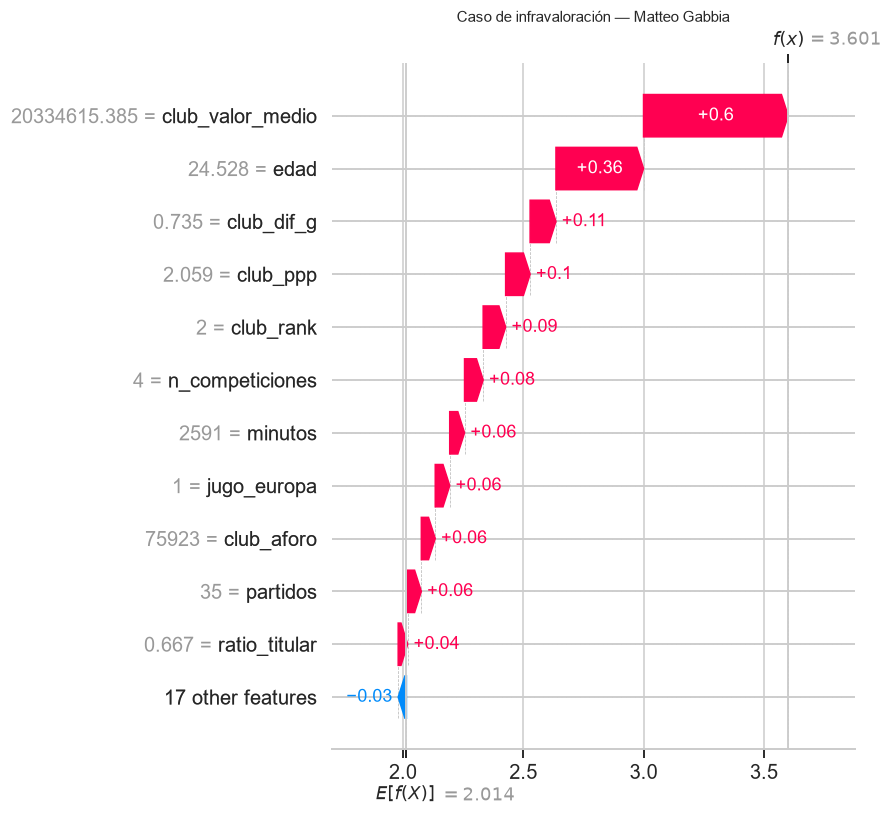


=== CONTRIBUCIONES SHAP ORDENADAS ===
        variable          valor   shap
club_valor_medio 20,334,615.385  0.601
            edad         24.528  0.364
      club_dif_g          0.735  0.107
        club_ppp          2.059  0.102
       club_rank          2.000  0.093
 n_competiciones              4  0.077
         minutos           2591  0.062
     jugo_europa              1  0.060
      club_aforo     75,923.000  0.058
        partidos             35  0.057
   ratio_titular          0.667  0.040
        position       Defender -0.039

Suma de contribuciones + valor esperado = 3.6006 (= f(x))


In [13]:
# --- Caso de infravaloración: selección y descomposición SHAP ---------------
# Se restringe a jugadores con temporada completa para que las métricas
# agregadas sean estables y la discrepancia no responda a pocos minutos.
cand = (te[(te["target_valor"] < te["est_inf"]) & (te["minutos"] >= 1800)]
        .nlargest(5, "señal"))
print("=== CANDIDATOS CON TEMPORADA COMPLETA ===")
print(cand[["name","club","liga","position","edad","partidos","minutos",
            "goles","asistencias","target_valor","pred_eur","est_inf"]]
      .to_string(index=False))

# Caso seleccionado
NOMBRE = "Matteo Gabbia"
i   = te.index[te["name"] == NOMBRE][0]
pos = te.index.get_loc(i)
f   = te.loc[i]

print(f"\n{'='*70}\nCASO DE INFRAVALORACIÓN — {f['name']}")
print(f"  {f['club']} ({f['liga']}) | {f['position']} | {f['edad']:.2f} años")
print(f"  {f['partidos']:.0f} partidos, {f['minutos']:.0f} min, "
      f"{f['goles']:.0f} goles, {f['asistencias']:.0f} asistencias")
print(f"  Tasación real {f['target_valor']/1e6:.2f} M€ | "
      f"estimación {f['pred_eur']/1e6:.2f} M€ | "
      f"intervalo 80% [{f['est_inf']/1e6:.2f} – {f['est_sup']/1e6:.2f}] M€")
print(f"  f(x) = {f['pred_log']:.3f} | E[f(X)] = {valor_esp:.3f} | "
      f"residuo = {f['residuo']:+.3f}")

# Gráfico de cascada
fig = plt.figure(figsize=(8, 5.5))
shap.plots.waterfall(expl[pos], max_display=12, show=False)
plt.title(f"Caso de infravaloración — {f['name']}", fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES / "fig14_waterfall_infravalorado.png", bbox_inches="tight")
plt.show()

# Tabla de contribuciones, para redactar el apartado 6.2 de la memoria
contrib = (pd.DataFrame({"variable": COLS,
                         "valor": te.loc[i, COLS].values,
                         "shap": shap_val[pos]})
           .assign(abs_shap=lambda x: x["shap"].abs())
           .sort_values("abs_shap", ascending=False)
           .drop(columns="abs_shap"))
print("\n=== CONTRIBUCIONES SHAP ORDENADAS ===")
print(contrib.head(12).to_string(index=False))
print(f"\nSuma de contribuciones + valor esperado = "
      f"{shap_val[pos].sum() + valor_esp:.4f} (= f(x))")

---
# 4. Empaquetado: función de inferencia

La guía del máster valora que el modelo pueda recibir nuevos valores y devolver una
predicción. Se implementa una función que encapsula el pipeline completo: recibe las
estadísticas de un jugador-temporada y devuelve el valor estimado con su intervalo, aplicando
internamente el factor de corrección de Duan y el índice de mercado de la temporada.

In [14]:
COLS_Q   = list(CUANT[0.5].feature_names_)
IDXCAT_Q = [COLS_Q.index(c) for c in CATS if c in COLS_Q]

def estima_valor(datos: dict, season: int = None, verbose: bool = True) -> dict:
    # Estima el valor de mercado de un jugador-temporada.
    # Las variables ausentes se imputan con la mediana del conjunto.
    def construye(columnas, idxcat):
        fila = {}
        for c in columnas:
            if c in datos and pd.notna(datos[c]):
                fila[c] = datos[c]
            elif c in CATS:
                fila[c] = "desconocido"
            else:
                fila[c] = float(a[c].median())
        X = pd.DataFrame([fila])[columnas]
        for c in CATS:
            if c in X.columns:
                X[c] = X[c].astype(str)
        return Pool(X, cat_features=idxcat)

    ind = INDICE.get(season, np.median(list(INDICE.values()))) if season \
          else np.median(list(INDICE.values()))

    log_pred = float(modelo.predict(construye(COLS, IDXCAT))[0])
    p_q = construye(COLS_Q, IDXCAT_Q)
    q = np.sort([float(CUANT[k].predict(p_q)[0]) for k in (0.1, 0.5, 0.9)])

    salida = {
        "valor_estimado_eur": float(np.exp(log_pred) * DUAN * ind),
        "intervalo_80_eur":  (float(np.exp(q[0]) * DUAN * ind),
                              float(np.exp(q[2]) * DUAN * ind)),
        "indice_mercado": float(ind),
        "log_pred": log_pred,
    }
    if verbose:
        v = salida["valor_estimado_eur"] / 1e6
        lo, hi = (x/1e6 for x in salida["intervalo_80_eur"])
        print(f"Valor estimado: {v:,.2f} M€   (intervalo 80%: {lo:,.2f} – {hi:,.2f} M€)")
    return salida

print("Función de inferencia definida.")
print(f"Modelo principal: {len(COLS)} vars | Cuantílicos: {len(COLS_Q)} vars")

Función de inferencia definida.
Modelo principal: 28 vars | Cuantílicos: 28 vars


In [15]:
# Prueba 1: caso real del conjunto de prueba (debe reproducir la predicción)
ref = te.iloc[0]
print(f"Caso real: {ref['name']} | {ref['club']} | {ref['edad']:.1f} años")
print(f"Valor de mercado observado: {ref['target_valor']/1e6:.2f} M€\n")
r1 = estima_valor({c: ref[c] for c in COLS}, season=int(ref["season"]))
print(f"\nPredicción almacenada en el notebook 2: {ref['pred_eur']/1e6:.2f} M€")
print(f"Diferencia: {abs(r1['valor_estimado_eur']-ref['pred_eur'])/1e6:.4f} M€")

Caso real: James Milner | Brighton & Hove Albion | 38.3 años
Valor de mercado observado: 1.00 M€

Valor estimado: 12.64 M€   (intervalo 80%: 6.82 – 38.82 M€)

Predicción almacenada en el notebook 2: 1.26 M€
Diferencia: 11.3745 M€


In [16]:
# Prueba 2: jugador hipotético
print("=== Delantero joven, gran temporada en un club medio ===")
estima_valor({
    "edad": 22, "height_in_cm": 182, "position": "Attack",
    "sub_position": "Centre-Forward", "foot": "right", "liga": "ES1",
    "partidos": 34, "minutos": 2900, "goles": 18, "asistencias": 7,
    "amarillas": 3, "rojas": 0,
    "goles_90": 18/(2900/90), "asistencias_90": 7/(2900/90),
    "ga_90": 25/(2900/90), "amarillas_90": 3/(2900/90),
    "min_por_partido": 2900/34, "ratio_titular": 0.92, "capitanias": 0,
    "partidos_liga": 32, "partidos_euro": 0, "n_competiciones": 2, "jugo_europa": 0,
    "club_ppp": 1.35, "club_dif_g": 0.15, "club_rank": 8,
    "club_valor_medio": 8_000_000, "club_aforo": 40_000,
}, season=2023)

print("\n=== Mismo jugador, diez años mayor ===")
estima_valor({
    "edad": 32, "height_in_cm": 182, "position": "Attack",
    "sub_position": "Centre-Forward", "foot": "right", "liga": "ES1",
    "partidos": 34, "minutos": 2900, "goles": 18, "asistencias": 7,
    "amarillas": 3, "rojas": 0,
    "goles_90": 18/(2900/90), "asistencias_90": 7/(2900/90),
    "ga_90": 25/(2900/90), "amarillas_90": 3/(2900/90),
    "min_por_partido": 2900/34, "ratio_titular": 0.92, "capitanias": 0,
    "partidos_liga": 32, "partidos_euro": 0, "n_competiciones": 2, "jugo_europa": 0,
    "club_ppp": 1.35, "club_dif_g": 0.15, "club_rank": 8,
    "club_valor_medio": 8_000_000, "club_aforo": 40_000,
}, season=2023)

=== Delantero joven, gran temporada en un club medio ===
Valor estimado: 456.66 M€   (intervalo 80%: 303.61 – 568.33 M€)

=== Mismo jugador, diez años mayor ===
Valor estimado: 115.47 M€   (intervalo 80%: 74.76 – 195.18 M€)


{'valor_estimado_eur': 115468555.02494523,
 'intervalo_80_eur': (74760527.2239783, 195180174.42220873),
 'indice_mercado': 7000000.0,
 'log_pred': 2.755499439395607}

---
## Cierre

**Ficheros generados:**

| Fichero | Contenido |
|---|---
| `reports/figures/fig9` a `fig16` | Figuras de interpretabilidad y validación |